In [25]:
from PIL import Image
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import time
from skimage.transform import resize
from skimage.io import imsave, imread
from scipy import ndimage
import scipy.optimize as opt
from scipy.ndimage import gaussian_filter
from scipy.ndimage import label

In [26]:
def find_centre_gaus(image_array, threshold):
    image_array_blurred = gaussian_filter(image_array, sigma=5)
    image_array_max = (image_array <= image_array.max()) & (image_array > (image_array.max() - image_array.max()*threshold))
    index_horizontal = np.array(range(0, image_array_max.shape[1]))
    image_array_weighted_horizontal = index_horizontal * image_array_max
    image_array_weighted_horizontal_filtered = image_array_weighted_horizontal[image_array_weighted_horizontal > 0]
    avg_horizontal = np.average(image_array_weighted_horizontal_filtered)
    # print("horizontal: ", avg_horizontal)

    index_vetical = np.array(range(0, image_array_max.shape[0]))
    image_array_weighted_vetical = index_vetical * image_array_max.transpose() # transposed to rotate 90 degrees
    image_array_weighted_vetical_filtered = image_array_weighted_vetical[image_array_weighted_vetical > 0]
    avg_vetical = np.average(image_array_weighted_vetical_filtered)
    # print("vertical: ", avg_vetical)

    # blurred_image = gaussian_filter(image_array, sigma=3)
    # blurred_image_max = (blurred_image <= blurred_image.max()) & (blurred_image > (blurred_image.max() - blurred_image.max()/8))
    
    # print("image array")
    # plt.imshow(image_array)
    # plt.show()
    # plt.figure()
    # plt.scatter(avg_horizontal, avg_vetical, color="red", s=4)
                
    # print("image array max threshold")
    # plt.imshow(image_array_max)
    # plt.show()
    # plt.scatter(avg_horizontal, avg_vetical, color="red", s=4)

    # print("blurred image")
    # plt.imshow(blurred_image)
    # plt.show()

    # print("blurred array max threshold")
    # plt.imshow(blurred_image_max)
    # plt.show()


    return avg_horizontal, avg_vetical

In [27]:
def is_above(centre_x, centre_y, target_x, target_y, margin):
    if np.abs(centre_x - target_x) > margin:
        return False
    if centre_y <= target_y:
        return False
    return True

def is_below(centre_x, centre_y, target_x, target_y, margin):
    if np.abs(centre_x - target_x) > margin:
        return False
    if centre_y >= target_y:
        return False
    return True

def is_left(centre_x, centre_y, target_x, target_y, margin):
    if np.abs(centre_y - target_y) > margin:
        return False
    if centre_x <= target_x:
        return False
    return True

def is_right(centre_x, centre_y, target_x, target_y, margin):
    if np.abs(centre_y - target_y) > margin:
        return False
    if centre_x >= target_x:
        return False
    return True

In [28]:
def find_centre_grid(image_array, threshold):
    image_array_blurred = gaussian_filter(image_array, sigma=5)
    # plt.imshow(image_array)
    # plt.show()
    # plt.imshow(image_array_blurred)
    # plt.show()
    image_array_max = (image_array_blurred <= image_array_blurred.max()) & (image_array_blurred > (image_array_blurred.max() - image_array_blurred.max()*threshold))
    
    labeled_array, num_features = label(image_array_max)
    # we can now find the centre of mass (and total mass) of each cluster

    cluster_indexes = np.unique(labeled_array)
    clusters_df = pd.DataFrame(cluster_indexes[1:], columns=["index"])
    clusters_df[["centre_horizontal", "centre_vertical"]] = clusters_df["index"].apply(lambda x: pd.Series(find_centre_gaus(labeled_array == x)))
    clusters_df["size"] = clusters_df["index"].apply(lambda x: (labeled_array == x).sum())
    clusters_df["radius_approximation"] = np.sqrt(clusters_df["size"]/np.pi)

    # print(clusters_df.head(20))
    # plt.imshow(image_array_max)
    # plt.scatter(clusters_df["centre_horizontal"], clusters_df["centre_vertical"])
    # plt.show()
    # print(num_features)

    # clusters_df = clusters_df[clusters_df["radius_approximation"] > clusters_df["radius_approximation"].max()/8]

    clusters_df.sort_values(by="size", ascending=False, inplace=True)



    clusters_df["is_centre"] = clusters_df["size"] == clusters_df["size"].max()

    centre_x = clusters_df[clusters_df["is_centre"] == True].iloc[0]["centre_horizontal"]
    centre_y = clusters_df[clusters_df["is_centre"] == True].iloc[0]["centre_vertical"]

    clusters_df["is_above"] = clusters_df.apply(lambda x: is_above(centre_x=centre_x, 
                                                                centre_y=centre_y,
                                                                target_x=x["centre_horizontal"],
                                                                target_y=x["centre_vertical"],
                                                                margin=30), axis=1)

    clusters_df["is_below"] = clusters_df.apply(lambda x: is_below(centre_x=centre_x, 
                                                                centre_y=centre_y,
                                                                target_x=x["centre_horizontal"],
                                                                target_y=x["centre_vertical"],
                                                                margin=30), axis=1)

    clusters_df["is_left"] = clusters_df.apply(lambda x: is_left(centre_x=centre_x, 
                                                                centre_y=centre_y,
                                                                target_x=x["centre_horizontal"],
                                                                target_y=x["centre_vertical"],
                                                                margin=30), axis=1)

    clusters_df["is_right"] = clusters_df.apply(lambda x: is_right(centre_x=centre_x, 
                                                                centre_y=centre_y,
                                                                target_x=x["centre_horizontal"],
                                                                target_y=x["centre_vertical"],
                                                                margin=30), axis=1)
    
    clusters_df["is_above"] = np.where(
        (clusters_df["is_above"] == True) & (clusters_df["centre_vertical"] == clusters_df[clusters_df["is_above"] == True]["centre_vertical"].max())
    , True, False)

    clusters_df["is_below"] = np.where(
        (clusters_df["is_below"] == True) & (clusters_df["centre_vertical"] == clusters_df[clusters_df["is_below"] == True]["centre_vertical"].min())
    , True, False)

    clusters_df["is_left"] = np.where(
        (clusters_df["is_left"] == True) & (clusters_df["centre_horizontal"] == clusters_df[clusters_df["is_left"] == True]["centre_horizontal"].max())
    , True, False)

    clusters_df["is_right"] = np.where(
        (clusters_df["is_right"] == True) & (clusters_df["centre_horizontal"] == clusters_df[clusters_df["is_right"] == True]["centre_horizontal"].min())
    , True, False)

    # print(clusters_df.head(10))
    # plt.imshow(image_array_max)
    # plt.scatter(clusters_df[clusters_df["is_above"] == True]["centre_horizontal"], clusters_df[clusters_df["is_above"] == True]["centre_vertical"], color="blue")
    # plt.scatter(clusters_df[clusters_df["is_below"] == True]["centre_horizontal"], clusters_df[clusters_df["is_below"] == True]["centre_vertical"], color="red")
    # plt.scatter(clusters_df[clusters_df["is_left"] == True]["centre_horizontal"], clusters_df[clusters_df["is_left"] == True]["centre_vertical"], color="orange")
    # plt.scatter(clusters_df[clusters_df["is_right"] == True]["centre_horizontal"], clusters_df[clusters_df["is_right"] == True]["centre_vertical"], color="green")
    # plt.show()

    clusters_df_filtered = clusters_df[
        (clusters_df["is_centre"] == True) |
        (clusters_df["is_above"] == True) |
        (clusters_df["is_below"] == True) |
        (clusters_df["is_left"] == True) |
        (clusters_df["is_right"] == True)
    ]

    # print(clusters_df.shape)
    # print("shape")
    # print(clusters_df_filtered.head())
    # Find centre using intersection
    x1 = clusters_df_filtered[clusters_df_filtered["is_above"] == True].iloc[0]["centre_horizontal"]
    y1 = clusters_df_filtered[clusters_df_filtered["is_above"] == True].iloc[0]["centre_vertical"]
    x2 = clusters_df_filtered[clusters_df_filtered["is_below"] == True].iloc[0]["centre_horizontal"]
    y2 = clusters_df_filtered[clusters_df_filtered["is_below"] == True].iloc[0]["centre_vertical"]

    x3 = clusters_df_filtered[clusters_df_filtered["is_left"] == True].iloc[0]["centre_horizontal"]
    y3 = clusters_df_filtered[clusters_df_filtered["is_left"] == True].iloc[0]["centre_vertical"]
    x4 = clusters_df_filtered[clusters_df_filtered["is_right"] == True].iloc[0]["centre_horizontal"]
    y4 = clusters_df_filtered[clusters_df_filtered["is_right"] == True].iloc[0]["centre_vertical"]

    vertical_line_gradient = (y2-y1)/(x2-x1)
    vertical_line_intercept = y1 - vertical_line_gradient * x1

    horizontal_line_gradient = (y3-y4)/(x3-x4)
    horizontal_line_intercept = y3 - horizontal_line_gradient * x3

    centre_grid_x = (vertical_line_intercept - horizontal_line_intercept) / (horizontal_line_gradient - vertical_line_gradient)
    centre_grid_y = (vertical_line_gradient * centre_grid_x) + vertical_line_intercept

    centre_single_peak_x = clusters_df[clusters_df["is_centre"] == True]["centre_horizontal"]
    centre_single_peak_y = clusters_df[clusters_df["is_centre"] == True]["centre_vertical"]

    return centre_grid_x, centre_grid_y, centre_single_peak_x, centre_single_peak_y

measurement:0, index:0
measurement:0, index:100
measurement:0, index:200
measurement:0, index:300
measurement:0, index:400
measurement:0, index:500
measurement:0, index:600
measurement:0, index:700
measurement:0, index:800
measurement:0, index:900
measurement:100, index:0
measurement:100, index:100
measurement:100, index:200
measurement:100, index:300
measurement:100, index:400
measurement:100, index:500
measurement:100, index:600
measurement:100, index:700
measurement:100, index:800
measurement:100, index:900
measurement:200, index:0
measurement:200, index:100
measurement:200, index:200
measurement:200, index:300
measurement:200, index:400
measurement:200, index:500
measurement:200, index:600
measurement:200, index:700
measurement:200, index:800
measurement:200, index:900
measurement:300, index:0
measurement:300, index:100
measurement:300, index:200
measurement:300, index:300
measurement:300, index:400
measurement:300, index:500
measurement:300, index:600
measurement:300, index:700
me

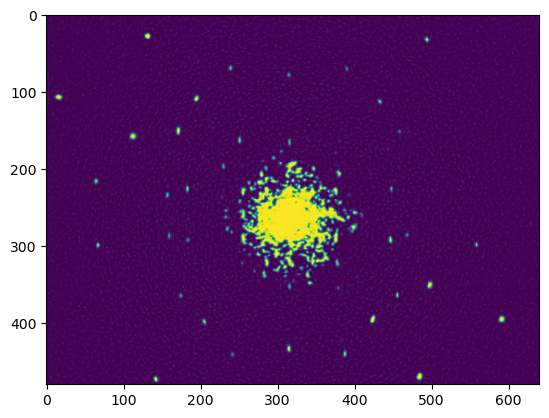

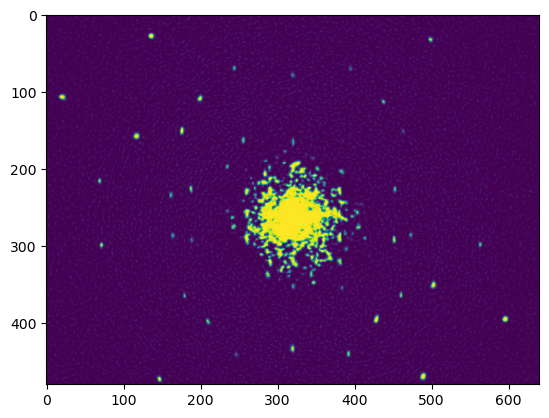

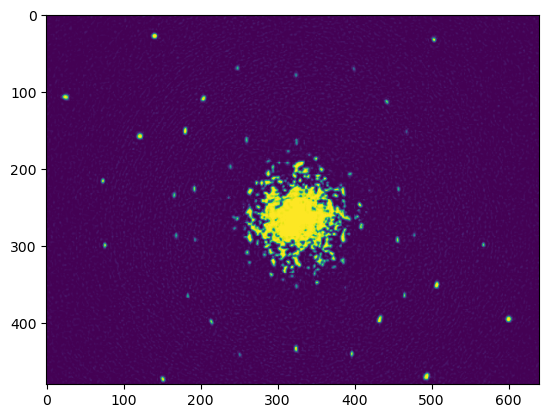

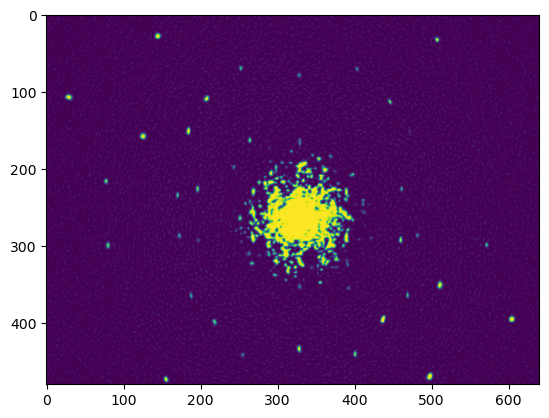

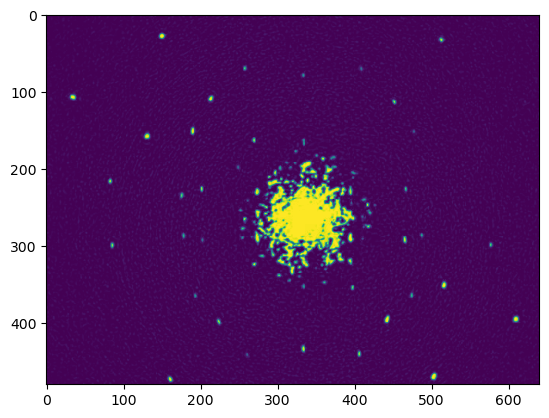

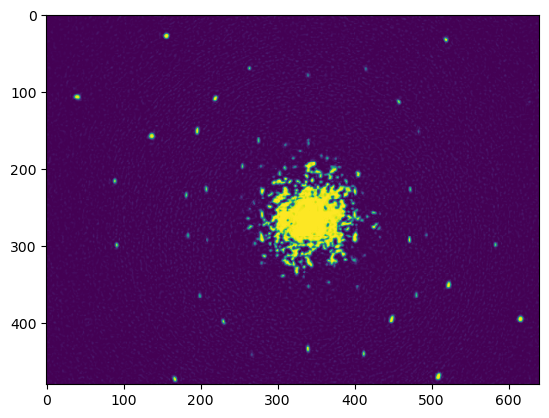

In [29]:
index_range = range(1000)
clean_df = pd.DataFrame(index=index_range, columns=["x_mean", "y_mean", "x_curve", "y_curve"])

measurement_range = [0, 100, 200, 300, 400, 500]

centre_single_peak_x_list_full = []
centre_single_peak_y_list_full = []

centre_single_peak_x_list_full_mean = []
centre_single_peak_y_list_full_mean = []

centre_single_peak_x_list_full_var = []
centre_single_peak_y_list_full_var = []

for measurement_index, measurement in enumerate(measurement_range):
    centre_single_peak_x_list = []
    centre_single_peak_y_list = []
    for index in index_range:
        image = Image.open(f'Sensitivity_exp_short/lens/dx_{measurement}um/image{index+1}.jpg')
        image_array = np.array(image)
        # centre_grid_x, centre_grid_y, centre_single_peak_x, centre_single_peak_y = find_centre_grid(image_array=image_array[:,:,1], threshold=0.5)
        centre_single_peak_x, centre_single_peak_y = find_centre_gaus(image_array=image_array[:,:,1], threshold=0.5)
        
        if index % 100 == 0: 
            print(f"measurement:{measurement}, index:{index}")
        centre_single_peak_x_list.append(centre_single_peak_x)
        centre_single_peak_y_list.append(centre_single_peak_y)
         
    
    centre_single_peak_x_list_full.append([])
    centre_single_peak_y_list_full.append([])

    centre_single_peak_x_list_full[measurement_index].append(centre_single_peak_x_list)
    centre_single_peak_y_list_full[measurement_index].append(centre_single_peak_y_list)

    centre_single_peak_x_list_full_mean.append(np.array(centre_single_peak_x_list).mean())
    centre_single_peak_y_list_full_mean.append(np.array(centre_single_peak_y_list).mean())
    
    centre_single_peak_x_list_full_var.append(np.array(centre_single_peak_x_list).var())
    centre_single_peak_y_list_full_var.append(np.array(centre_single_peak_y_list).var())

    plt.figure(measurement)
    plt.imshow(image_array[:,:,1])


<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
/var/folders/qn/3918x07s7pz7dgl96fx2slhm0000gn/T/ipykernel_31691/588298312.py:6: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("$\Delta x' \, (\mu m)$")


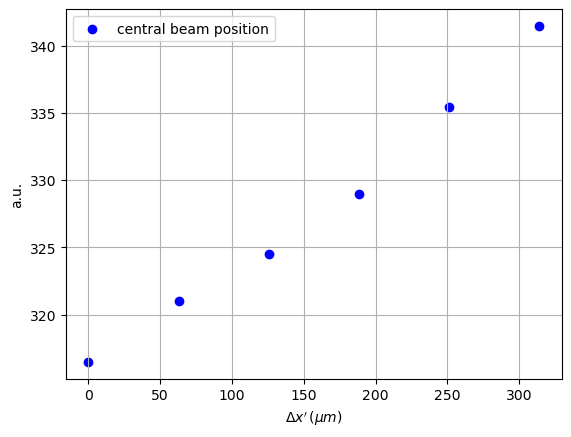

In [30]:
err_peak = np.sqrt(centre_single_peak_x_list_full_var)
measurement_range_adjusted = 0.628 * np.array(measurement_range)

plt.figure(1)
plt.scatter(measurement_range_adjusted, centre_single_peak_x_list_full_mean, color="blue", label="central beam position")
plt.xlabel("$\Delta x' \, (\mu m)$")
plt.ylabel("a.u.")
plt.grid("on")
plt.legend()
plt.show()

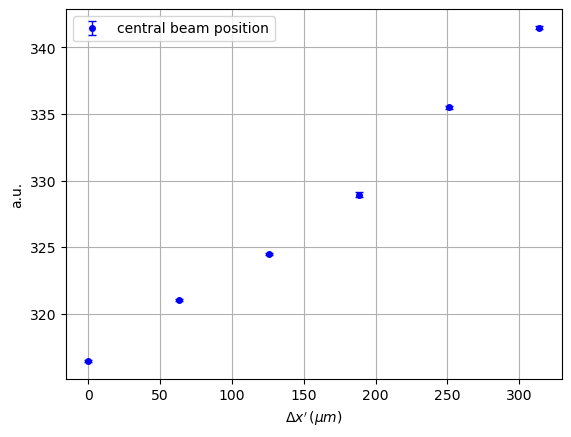

In [31]:
plt.figure(1)

# 2. Use errorbar instead of scatter
# plt.errorbar(measurement_range_adjusted, centre_grid_x_list_full_mean, 
#              yerr=err_grid, fmt='o', color="red", label="grid line intersection", 
#              capsize=3, elinewidth=1, markersize=4)

plt.errorbar(measurement_range_adjusted, centre_single_peak_x_list_full_mean, 
             yerr=err_peak, fmt='o', color="blue", label="central beam position", 
             capsize=3, elinewidth=1, markersize=4)

plt.xlabel(r"$\Delta x' \, (\mu m)$")
plt.ylabel("a.u.")
plt.grid(True)
plt.legend()
plt.show()

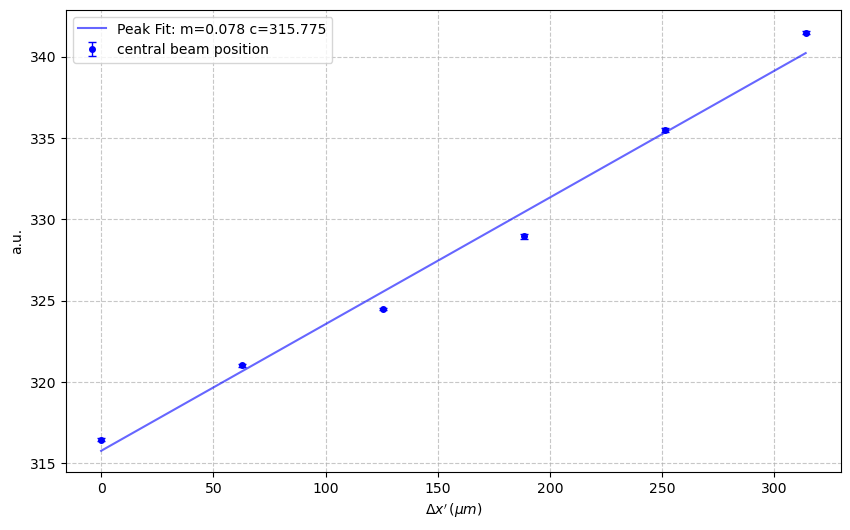

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Define the linear model function
def linear_model(x, m, c):
    return m * x + c

# 2. Perform the fits (including weights based on error)
# We use sigma=err to perform a Weighted Least Squares fit

popt_peak, _ = curve_fit(linear_model, measurement_range_adjusted, 
                         centre_single_peak_x_list_full_mean, sigma=err_peak)

# 3. Generate points for the fit lines
x_fit = np.linspace(min(measurement_range_adjusted), max(measurement_range_adjusted), 100)
y_fit_peak = linear_model(x_fit, *popt_peak)

plt.figure(1, figsize=(10, 6))

# Plot Data with Error Bars

plt.errorbar(measurement_range_adjusted, centre_single_peak_x_list_full_mean, 
             yerr=err_peak, fmt='o', color="blue", label="central beam position", 
             capsize=3, elinewidth=1, markersize=4, linestyle='None')

# Plot Linear Fit Lines
plt.plot(x_fit, y_fit_peak, color="blue", alpha=0.6, 
         label=f"Peak Fit: m={popt_peak[0]:.3f} c={popt_peak[1]:.3f}")

plt.xlabel(r"$\Delta x' \, (\mu m)$")
plt.ylabel("a.u.")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [ ]:
signal_peak = linear_model(measurement_range_adjusted, *popt_peak)
snr_peak = signal_peak / err_peak

popt_snr, _ = curve_fit(linear_model, measurement_range_adjusted, 
                         snr_peak)

# 3. Generate points for the fit lines
x_fit = np.linspace(min(measurement_range_adjusted), max(measurement_range_adjusted), 100)
y_fit_snr = linear_model(x_fit, *popt_snr)

def find_y_1(m, c):
    x = (1-c)/m
    return x

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/var/folders/qn/3918x07s7pz7dgl96fx2slhm0000gn/T/ipykernel_31691/2164345470.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax2.plot(x_fit, y_fit_snr, color="black", alpha=0.3, label=f"peak SNR Fit y==1 @ {find_y_1(*popt_snr):.2f} $\mu m$")


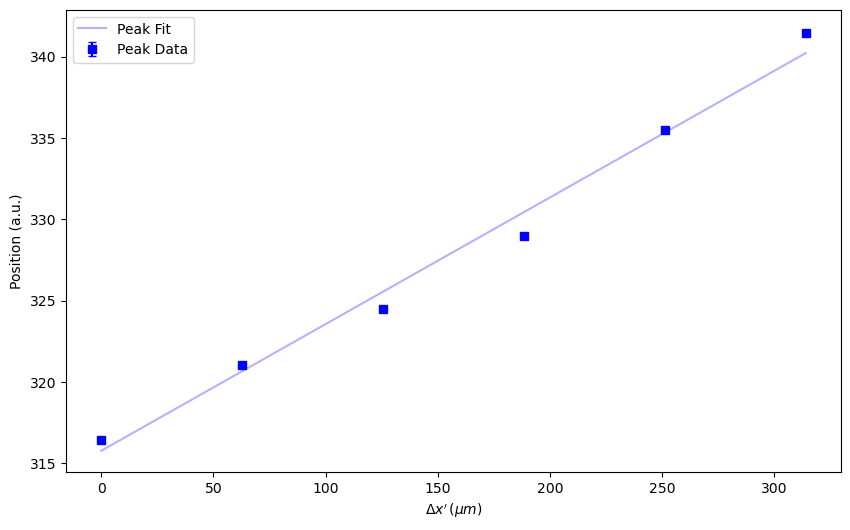

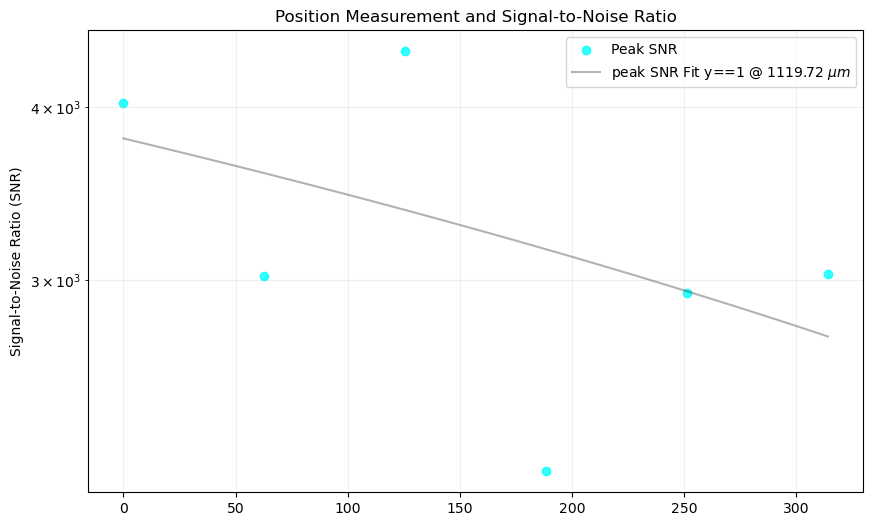

In [39]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Fit and Data on Left Axis
ax1.errorbar(measurement_range_adjusted, centre_single_peak_x_list_full_mean, 
             yerr=err_peak, fmt='s', color="blue", label="Peak Data", capsize=3, linestyle='None')
ax1.plot(measurement_range_adjusted, signal_peak, color="blue", alpha=0.3, label="Peak Fit")

ax1.set_xlabel(r"$\Delta x' \, (\mu m)$")
ax1.set_ylabel("Position (a.u.)")
ax1.legend(loc='upper left')

# Create a twin axis for SNR
fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.scatter(measurement_range_adjusted, snr_peak, color="cyan", alpha=0.8, label="Peak SNR")

ax2.plot(x_fit, y_fit_snr, color="black", alpha=0.3, label=f"peak SNR Fit y==1 @ {find_y_1(*popt_snr):.2f} $\mu m$")

ax2.set_ylabel("Signal-to-Noise Ratio (SNR)")
ax2.set_yscale('log') # SNR is often best viewed on a log scale
ax2.legend(loc='upper right')

plt.title("Position Measurement and Signal-to-Noise Ratio")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

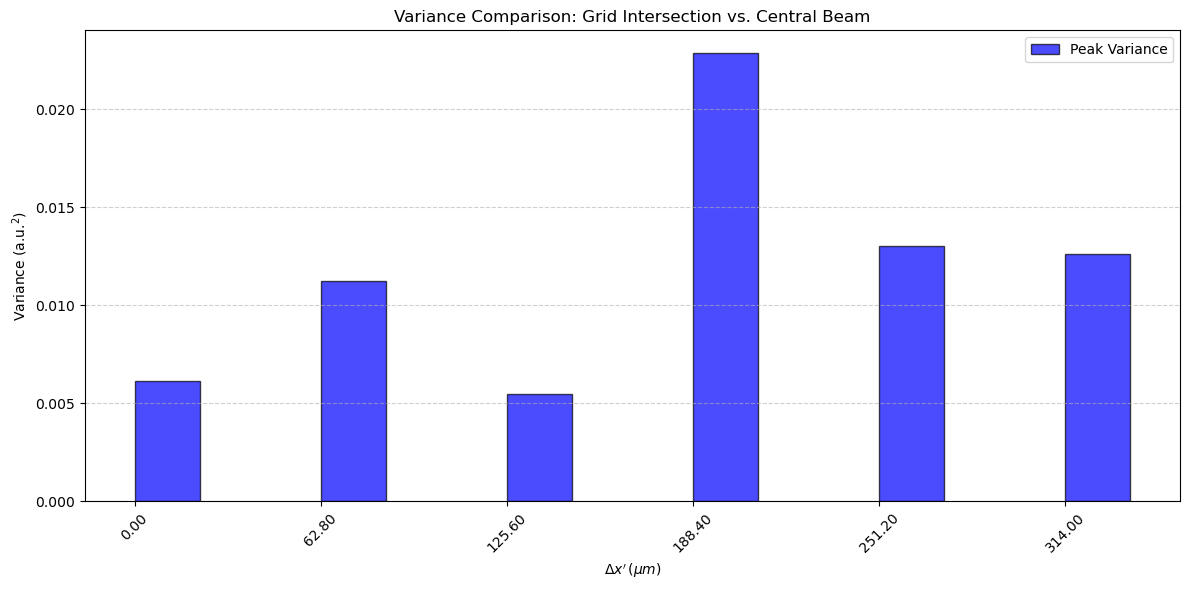

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup the positions for the bars
x = np.arange(len(measurement_range_adjusted))  # the index locations
width = 0.35  # the width of each individual bar

plt.figure(figsize=(12, 6))

# 2. Create the double bars
# We shift the first set by -width/2 and the second by +width/2
plt.bar(x + width/2, centre_single_peak_x_list_full_var, width, 
        label='Peak Variance', color='blue', alpha=0.7, edgecolor='black')

# 3. Formatting
plt.xlabel(r"$\Delta x' \, (\mu m)$")
plt.ylabel(r"Variance (a.u.$^2$)")
plt.title("Variance Comparison: Grid Intersection vs. Central Beam")

# Set the x-ticks to be the actual adjusted measurement values
plt.xticks(x, [f"{val:.2f}" for val in measurement_range_adjusted], rotation=45)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()